# Historical VaR: full revaluation vs PCA-greeks projection

The roadmap step after the factor model: 1-day 99% VaR of the call-spread
book, computed two ways over the *same* historical scenario set, to test
whether the PCA-factor greeks can stand in for per-scenario revaluation. The
motivation is practical: the real book holds options that need simulation to
value, so full historical reval costs n_scenarios expensive valuations per
position. The greeks route values each position a handful of times (base + a
few bumps) and projects every scenario from precomputed shocks — the question
is what that gives up at the 99% quantile.

**Book**: close of the last date, 2026-05-12 — 259 spreads / 518 legs, net
**long** vega ≈ $160k/vol pt (years of spot drift have pushed the old short
strikes deep ITM, flipping the sign the spreads had at inception) and net
short delta ≈ −$48M per 100% of spot.

**Scenarios**: every historical day pair (3,138 after dropping post-gap
moves) is one joint shock — the spot return, the fixed-moneyness pillar-grid
vol change, the zero-rate and implied-div changes at each leg's TTM, and the
calendar gap dt. Repricing samples the shocked grid at each leg's *new*
moneyness and *dt-decayed* lookup TTM, so smile slide and term roll-down
materialize on the as-of surface — the sticky-strike-with-roll basis of
[roll_in_pca.ipynb](roll_in_pca.ipynb) turned into a scenario engine. The BS
time input stays at the base TTM: scenario P&L is pure market-shock P&L, no
deterministic theta/funding. The factor model is the headline vega-weighted
roll-in fit (in-sample over the same history, as historical VaR always is).

Headline number: the **delta-hedged** book (plain BS delta, as the framework
prescribes). The raw number is reported too, but it is dominated by outright
delta.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vol_pca import load_surfaces, simulate_book, fit_pca
from vol_pca.factors import factor_scores, sticky_strike_dsigma
from vol_pca.var import (build_book, build_scenarios, full_reval_pnl,
                         greeks_pnl, hist_var, scenario_dsigma)

C_FULL, C_TAIL = "#2a78d6", "#e34948"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})

sd = load_surfaces("SPX_volSurface 2.csv")
_, bucket_vega_hist, _ = simulate_book(sd)     # only needed for the PCA weights
normal = np.diff(sd.dates).astype(int) <= 7    # drop post-data-gap moves
vega_w = np.abs(bucket_vega_hist[normal]).mean(axis=0)

book = build_book(sd)                          # close-of-day book, last date
scen = build_scenarios(sd, book, mask=normal)
model = fit_pca(sticky_strike_dsigma(sd, include_roll=True),   # roll-in basis
                fit_mask=normal, weights=vega_w)

print(f"as-of {book.date}: {book.n_legs // 2} spreads / {book.n_legs} legs, "
      f"book value ${(book.units * book.v0).sum() / 1e6:,.1f}M")
print(f"net delta ${book.net_delta * book.spot / 1e6:,.1f}M per 100% spot; net vega "
      f"${(book.units * book.vega0).sum() * 0.01 / 1e3:,.0f}k/vol pt (long)")
print(f"scenarios: {len(scen)} historical 1-day moves "
      f"({(~normal).sum()} post-gap moves dropped)")


as-of 2026-05-12: 259 spreads / 518 legs, book value $-20.3M
net delta $-47.7M per 100% spot; net vega $160k/vol pt (long)
scenarios: 3138 historical 1-day moves (2 post-gap moves dropped)


## Method 1: full revaluation

Reprice all 518 legs under each of the 3,138 scenarios — 1.63M Black-Scholes
valuations. Trivial here (well under a second), but this is the budget the
greeks method is trying to cut when each valuation is a Monte-Carlo run. The
hedged distribution is fat-tailed on both sides: the left tail is vol-crush
days (the book is net long vega), the right tail big-move days (net long
gamma) and vol spikes.


full revaluation: 1,625,484 option valuations
         delta-hedged     raw
VaR 99%         183.2  1235.8
VaR 95%          99.0   767.7   ($k, 1-day)


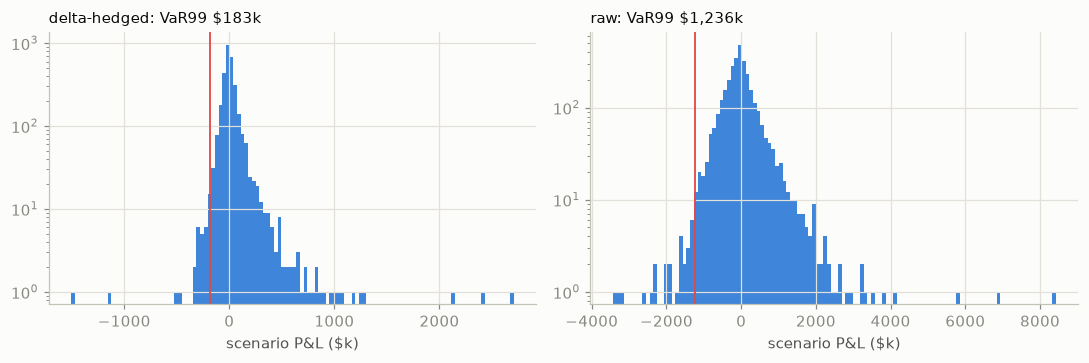

In [2]:
pnl_full = full_reval_pnl(book, scen)          # 3,138 x 518 BS revaluations
dS = book.spot * (scen.ratio - 1.0)
hedge = book.net_delta * dS                    # plain BS delta hedge
pnl_full_h = pnl_full - hedge

var_tab = pd.DataFrame(
    {"delta-hedged": [hist_var(pnl_full_h, l) / 1e3 for l in (0.99, 0.95)],
     "raw": [hist_var(pnl_full, l) / 1e3 for l in (0.99, 0.95)]},
    index=["VaR 99%", "VaR 95%"])
print(f"full revaluation: {len(scen) * book.n_legs:,} option valuations")
print(var_tab.round(1).to_string() + "   ($k, 1-day)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, p, name in ((axes[0], pnl_full_h, "delta-hedged"),
                    (axes[1], pnl_full, "raw")):
    ax.hist(p / 1e3, bins=120, color=C_FULL, alpha=0.9)
    ax.axvline(-hist_var(p) / 1e3, color=C_TAIL, lw=1.2)
    ax.set_yscale("log")
    ax.set_title(f"{name}: VaR99 ${hist_var(p) / 1e3:,.0f}k", loc="left",
                 fontsize=10)
    ax.set_xlabel("scenario P&L ($k)")
plt.tight_layout()
plt.show()


## Method 2: greeks projection

One greeks pass on the as-of date only:

- **delta, gamma** — analytic here; 2 spot-bump revaluations on a real book
- **bucketed vega** → factor exposures `E_k = (bucket_vega / w) · L_k` on the
  roll-in model; on a real book, k bump-revaluations along the factor loading
  shapes give the `E_k` directly — no 104 per-pillar bumps needed
- **bucketed vanna** — the spot-vol cross, paired with the k-factor
  reconstruction of each scenario's Δσ
- **rho / div** — per-leg 1bp-bump sensitivities

Each scenario then costs **zero** option valuations:

    pnl ≈ delta·dS + ½·gamma·dS² + [bucket_vega·μ + Σ_k E_k·f_k]
          + bucket_vanna·(recon Δσ_k)·dS + rho·Δr + div·Δq

The factor scores `f_k` are *scenario-consistent*: each scenario's pillar Δσ
is sampled on the as-of surface with the same re-anchoring as the factor
basis (grid lookups only, no option valuations), then scored with the
historically fitted loadings. Reusing the fitting sample's own historical
scores is cheaper still but noticeably worse — quantified at the end.


In [3]:
ks = [3, 5, 10, model.n_components]
ds_scen = scenario_dsigma(book, scen)   # (n_scen, 104) pillar moves: lookups only
est, parts = greeks_pnl(book, scen, model, ks, dsigma_scen=ds_scen)

rows = [{"method": "full reval", "VaR99 hedged": hist_var(pnl_full_h) / 1e3,
         "gap": np.nan, "VaR95 hedged": hist_var(pnl_full_h, 0.95) / 1e3,
         "VaR99 raw": hist_var(pnl_full) / 1e3}]
for k in ks:
    ph = est[k] - hedge
    rows.append({"method": f"greeks k={k}", "VaR99 hedged": hist_var(ph) / 1e3,
                 "gap": hist_var(ph) / hist_var(pnl_full_h) - 1,
                 "VaR95 hedged": hist_var(ph, 0.95) / 1e3,
                 "VaR99 raw": hist_var(est[k]) / 1e3})
tab = pd.DataFrame(rows).set_index("method")
tab["gap"] = tab["gap"].map(lambda g: "" if pd.isna(g) else f"{g:+.1%}")
print(tab.round(1).to_string() + "   ($k, 1-day)")


              VaR99 hedged    gap  VaR95 hedged  VaR99 raw
method                                                    
full reval           183.2                 99.0     1235.8
greeks k=3           165.7  -9.6%          90.8     1275.1
greeks k=5           190.2  +3.8%         101.1     1265.8
greeks k=10          184.9  +0.9%         100.6     1249.6
greeks k=104         183.2  -0.0%          98.7     1234.9   ($k, 1-day)


## How close is the projection, scenario by scenario?

The bulk of the distribution is easy — R² vs full reval sits at 0.93–0.96 for
every k. What k buys is the tail: the p99 projection error falls from $104k
(k=3) to $56k (k=10) to $30k (all factors), the mean error on the worst-1%
scenarios from $58k to $23k, and k=10 identifies 28 of the 31 worst-1%
scenarios. At the quantile itself, k=3 understates hedged VaR99 by 10%, k=5
overshoots by 4%, k=10 lands within 1% — the same "stress days need k≈10"
conclusion as the roll-in factor study, now measured where it matters.


        R2  err std  |err| p99  worst-1% |err| tail overlap
k                                                          
3    0.952   30.636    103.740          57.885        25/31
5    0.933   36.098     79.929          33.676        27/31
10   0.950   31.172     55.798          22.900        28/31
104  0.963   26.701     29.883          17.617        30/31   (errors $k, hedged)


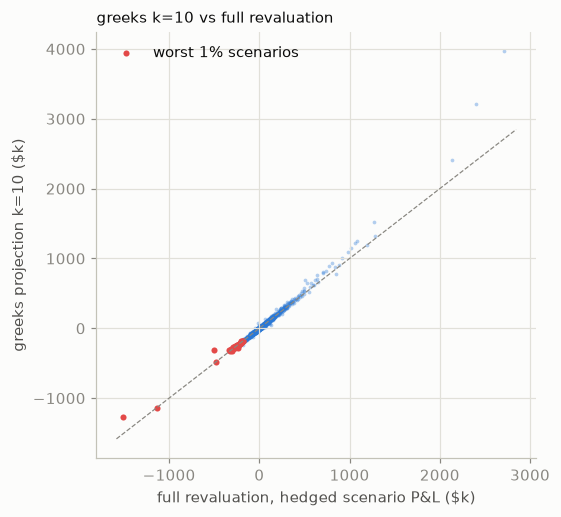

In [4]:
worst = np.argsort(pnl_full_h)[:len(scen) // 100]     # worst 1% = 31 scenarios
rows = []
for k in ks:
    e = pnl_full_h - (est[k] - hedge)
    o = np.argsort(est[k] - hedge)[:len(worst)]
    rows.append({"k": k, "R2": 1 - e.var() / pnl_full_h.var(),
                 "err std": e.std() / 1e3,
                 "|err| p99": np.percentile(np.abs(e), 99) / 1e3,
                 "worst-1% |err|": np.abs(e[worst]).mean() / 1e3,
                 "tail overlap": f"{len(set(worst) & set(o))}/{len(worst)}"})
print(pd.DataFrame(rows).set_index("k").round(3).to_string()
      + "   (errors $k, hedged)")

fig, ax = plt.subplots(figsize=(5.2, 4.8))
ax.scatter(pnl_full_h / 1e3, (est[10] - hedge) / 1e3, s=6, alpha=0.35,
           color=C_FULL, lw=0)
ax.scatter(pnl_full_h[worst] / 1e3, (est[10] - hedge)[worst] / 1e3, s=16,
           color=C_TAIL, lw=0, label="worst 1% scenarios")
lims = np.array([pnl_full_h.min(), pnl_full_h.max()]) / 1e3 * 1.05
ax.plot(lims, lims, color="#898781", lw=0.8, ls="--")
ax.set_xlabel("full revaluation, hedged scenario P&L ($k)")
ax.set_ylabel("greeks projection k=10 ($k)")
ax.legend(loc="upper left")
ax.set_title("greeks k=10 vs full revaluation", loc="left", fontsize=10)
plt.tight_layout()
plt.show()


## What the tail is made of

The worst hedged scenarios are the big vol-crush days — 2020-03-19 (−$1.5M),
2018-02-07 (the day after Volmageddon, −$1.1M) — as a net-long-vega book
should fear. Even the all-factor projection misses the worst scenario by
~$0.2M: that residual is linearization error (vega convexity on an extreme
vol move), not factor truncation — yet the VaR99 *quantile* barely notices,
because misses on a handful of extreme scenarios don't move the 31st-worst
loss. The raw book's tail is entirely different: its −$3.4M worst scenarios
are the +7–10% rebound days (March 2020, 2025-04-09) hitting the −$48M delta
— exactly what the hedge removes.


In [5]:
o = np.argsort(pnl_full_h)[:10]
wtab = pd.DataFrame({
    "spot ret": [f"{r:+.1%}" for r in scen.ratio[o] - 1],
    "full reval": pnl_full_h[o] / 1e3, "k=3": (est[3] - hedge)[o] / 1e3,
    "k=10": (est[10] - hedge)[o] / 1e3,
    "k=all": (est[model.n_components] - hedge)[o] / 1e3,
}, index=pd.Index(scen.dates[o], name="scenario"))
print("worst 10 hedged scenarios ($k):")
print(wtab.round(0).to_string())

o = np.argsort(pnl_full)[:5]
print("\nworst 5 raw scenarios ($k):")
print(pd.DataFrame(
    {"spot ret": [f"{r:+.1%}" for r in scen.ratio[o] - 1],
     "raw": pnl_full[o] / 1e3, "hedged": pnl_full_h[o] / 1e3},
    index=pd.Index(scen.dates[o], name="scenario")).round(0).to_string())


worst 10 hedged scenarios ($k):
           spot ret  full reval     k=3    k=10   k=all
scenario                                               
2020-03-19    +0.5%     -1508.0 -1217.0 -1275.0 -1283.0
2018-02-07    -0.5%     -1133.0  -998.0 -1137.0 -1103.0
2020-03-23    -2.9%      -497.0  -345.0  -305.0  -367.0
2021-11-29    +1.3%      -477.0  -457.0  -489.0  -471.0
2020-06-22    +0.6%      -332.0  -329.0  -317.0  -320.0
2020-04-24    +1.4%      -324.0  -288.0  -324.0  -326.0
2018-02-22    +0.1%      -309.0  -222.0  -299.0  -263.0
2019-08-26    +1.1%      -304.0  -287.0  -330.0  -316.0
2024-08-06    +1.0%      -303.0  -241.0  -303.0  -287.0
2018-02-12    +1.4%      -297.0  -263.0  -303.0  -306.0

worst 5 raw scenarios ($k):
           spot ret     raw  hedged
scenario                           
2020-03-13    +9.3% -3442.0   984.0
2025-04-09    +9.5% -3342.0  1193.0
2020-03-24    +9.4% -3193.0  1279.0
2020-04-06    +7.0% -2585.0   767.0
2020-03-17    +6.0% -2356.0   501.0


## Which greeks matter, and a shortcut not to take

Ablation at k=10: the factor-vol term carries the VaR (dropping it collapses
hedged VaR99 to $35k); gamma is essential (dropping it *overstates* VaR99 by
31% — long gamma cushions the big-move scenarios); vanna and div each leave the
VaR99 quantile essentially unchanged (<2%, as does rate) though both
contribute visibly to the bulk fit (R² 0.950 → 0.925 without either —
the div term partly absorbing the implied-div snap noise the attribution
flagged).

The tempting shortcut — reusing the factor scores from the fitting sample
instead of re-scoring each scenario on the as-of surface — costs real
accuracy: R² drops to 0.81 and hedged VaR99 is understated by 12%. The
historical slide and roll were realized on each day's own surface, not
today's. Scenario-consistent scores are grid lookups only, so there is no
valuation budget to be saved by skipping them.


In [6]:
base_h = est[10] - hedge
e0 = pnl_full_h - base_h
print(f"ablation at k=10 (hedged; full-reval VaR99 "
      f"${hist_var(pnl_full_h) / 1e3:,.1f}k, greeks "
      f"${hist_var(base_h) / 1e3:,.1f}k, R2 {1 - e0.var() / pnl_full_h.var():.3f}):")
for name, term in [("vol (k=10)", parts["vol"][10]), ("gamma", parts["gamma"]),
                   ("vanna", parts["vanna"][10]), ("rate", parts["rate"]),
                   ("div", parts["div"])]:
    e = pnl_full_h - (base_h - term)
    print(f"  drop {name:>10}: VaR99 ${hist_var(base_h - term) / 1e3:8,.1f}k   "
          f"R2 {1 - e.var() / pnl_full_h.var():+.3f}")

sc_hist = factor_scores(sticky_strike_dsigma(sd, include_roll=True)[normal], model)
est_h, _ = greeks_pnl(book, scen, model, [10], scores=sc_hist)
e = pnl_full_h - (est_h[10] - hedge)
print(f"\nhistorical-scores shortcut at k=10 (fitting-sample scores instead of "
      f"as-of-surface scores):\n  R2 {1 - e.var() / pnl_full_h.var():.3f}, "
      f"VaR99 hedged ${hist_var(est_h[10] - hedge) / 1e3:,.1f}k "
      f"({hist_var(est_h[10] - hedge) / hist_var(pnl_full_h) - 1:+.1%} vs full reval)")


ablation at k=10 (hedged; full-reval VaR99 $183.2k, greeks $184.9k, R2 0.950):
  drop vol (k=10): VaR99 $    35.3k   R2 +0.587
  drop      gamma: VaR99 $   239.6k   R2 +0.773
  drop      vanna: VaR99 $   183.2k   R2 +0.925
  drop       rate: VaR99 $   186.5k   R2 +0.949
  drop        div: VaR99 $   182.3k   R2 +0.925



historical-scores shortcut at k=10 (fitting-sample scores instead of as-of-surface scores):
  R2 0.813, VaR99 hedged $160.5k (-12.4% vs full reval)


## Rolling check: the whole history, not one as-of date

The comparison above leans on a single book and base surface. To settle k and
the third-order-equity question on more evidence, the backtest recomputes both
VaRs for **every as-of date from one year in** — 2,889 books, 2015-01 through
2026-05, ~4.6B benchmark valuations (`scripts/run_var_rolling.py`, ~7 minutes
on 22 cores, cached in `data/var_rolling.csv`) — applying the same
whole-history scenario set to each day's book (in-sample throughout: this is
a methodology comparison, not an exceedance backtest). Configs: k ∈ {3, 4, 5,
10}, each with and without the third-order equity term ⅙·speed·dS³, where
speed = the book's ∂³V/∂S³ from a 5-point spot stencil — two extra spot bumps
per position on top of the delta/gamma pair.

The rolling books vary far more than the scenario set does: net vega swings
between −$376k and +$208k/vol pt (short vega on 43% of days), so both signs
of the vol exposure — and the 2018 and 2020 vol regimes — are covered.


In [7]:
import pathlib

cache = pathlib.Path("data/var_rolling.csv")
if cache.exists():
    roll = pd.read_csv(cache, parse_dates=["date"]).set_index("date")
else:                                   # ~7 min on a multicore box
    from vol_pca.var import rolling_var_backtest
    roll = rolling_var_backtest(sd, model, ks=(3, 4, 5, 10), start=252,
                                mask=normal)
    cache.parent.mkdir(exist_ok=True)
    roll.to_csv(cache)

print(f"{len(roll)} as-of dates {roll.index[0].date()} .. {roll.index[-1].date()}; "
      f"net vega ${roll.net_vega.min() / 1e3:,.0f}k .. "
      f"${roll.net_vega.max() / 1e3:,.0f}k/vol pt "
      f"(short vega on {(roll.net_vega < 0).mean():.0%} of days)")

def gap_table(side):
    rows = []
    for k in (3, 4, 5, 10):
        for tag, cfg in (("", "plain"), ("c", "+cube")):
            gap = roll[f"g{k}{tag}_{side}"] / roll[f"full_{side}"] - 1
            rows.append({"k": k, "cfg": cfg,
                         "mean gap %": gap.mean() * 100,
                         "mean |gap| %": gap.abs().mean() * 100,
                         "med |gap| %": gap.abs().median() * 100,
                         "p95 |gap| %": gap.abs().quantile(0.95) * 100})
    return pd.DataFrame(rows).set_index(["k", "cfg"]).round(2)

print("\nhedged VaR99 gap vs full reval:")
print(gap_table("h").to_string())
print("\nraw VaR99 gap vs full reval:")
print(gap_table("raw").to_string())
print()
for k in (3, 4, 5, 10):
    g0 = (roll[f"g{k}_h"] / roll["full_h"] - 1).abs()
    g1 = (roll[f"g{k}c_h"] / roll["full_h"] - 1).abs()
    print(f"k={k:>2}: cube reduces the hedged |gap| on {(g1 < g0).mean():.0%} "
          f"of days; days over 10%: {(g0 > 0.10).mean():.0%} -> {(g1 > 0.10).mean():.0%}")


2889 as-of dates 2015-01-30 .. 2026-05-12; net vega $-376k .. $208k/vol pt (short vega on 43% of days)

hedged VaR99 gap vs full reval:
          mean gap %  mean |gap| %  med |gap| %  p95 |gap| %
k  cfg                                                      
3  plain       -2.14          7.12         5.94        17.79
   +cube       -1.51          6.66         5.43        16.99
4  plain       -1.61          6.26         4.73        16.63
   +cube       -0.95          5.64         4.30        15.16
5  plain        1.54          6.08         4.71        15.77
   +cube        2.25          5.68         4.33        15.03
10 plain        2.01          4.97         3.00        16.38
   +cube        2.47          4.74         2.84        15.42

raw VaR99 gap vs full reval:
          mean gap %  mean |gap| %  med |gap| %  p95 |gap| %
k  cfg                                                      
3  plain        1.66          3.28         2.83         7.74
   +cube        1.50          3.36       

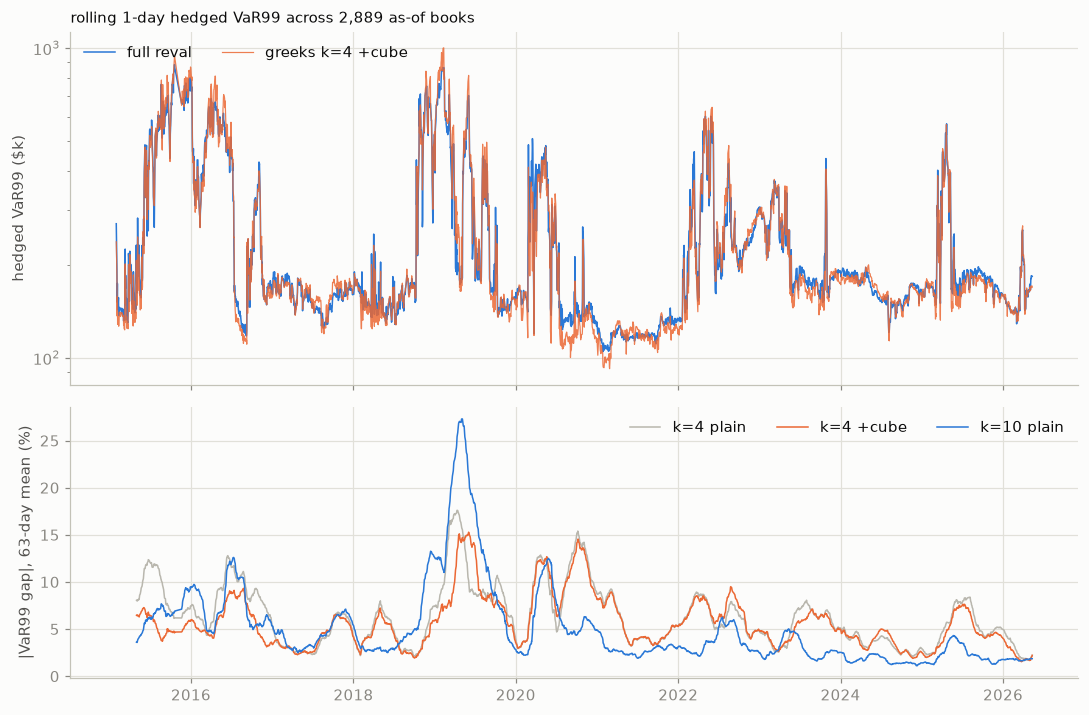

hardest as-of date, 2020-03-16 (COVID peak; hedged VaR99 $511k): greeks understate by k=3 56%, k=4 63%, k=5 66%, k=10 61% — the cube changes none of them


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.6), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1.0]})
ax = axes[0]
ax.plot(roll.index, roll.full_h / 1e3, color=C_FULL, lw=1.0, label="full reval")
ax.plot(roll.index, roll.g4c_h / 1e3, color="#eb6834", lw=0.8, alpha=0.85,
        label="greeks k=4 +cube")
ax.set_yscale("log")
ax.set_ylabel("hedged VaR99 ($k)")
ax.legend(loc="upper left", ncols=2)
ax.set_title("rolling 1-day hedged VaR99 across 2,889 as-of books",
             loc="left", fontsize=10)

ax = axes[1]
for col, c, lbl in (("g4_h", "#b9b7ae", "k=4 plain"),
                    ("g4c_h", "#eb6834", "k=4 +cube"),
                    ("g10_h", C_FULL, "k=10 plain")):
    gap = (roll[col] / roll.full_h - 1).abs().rolling(63).mean() * 100
    ax.plot(roll.index, gap, color=c, lw=1.0, label=lbl)
ax.set_ylabel("|VaR99 gap|, 63-day mean (%)")
ax.legend(loc="upper right", ncols=3)
plt.tight_layout()
plt.show()

d = roll.loc["2020-03-16"]
print("hardest as-of date, 2020-03-16 (COVID peak; hedged VaR99 "
      f"${d.full_h / 1e3:,.0f}k): greeks understate by "
      + ", ".join(f"k={k} {1 - d[f'g{k}_h'] / d.full_h:.0%}" for k in (3, 4, 5, 10))
      + " — the cube changes none of them")


### Verdict on third-order equity — and a more honest read on k

- **Hedged VaR: include it.** The cube term is a small, real improvement —
  mean |gap| 7.1% → 6.7% (k=3), 6.3% → 5.6% (k=4), 6.1% → 5.7% (k=5) —
  helping on ~60% of days at k=3–4 and cutting the days with a >10% gap from
  19% to 15% at k=4. The single-date test above, where it slightly hurt, was
  not representative.
- **Raw VaR**: neutral to slightly negative at k≤5 (3.3% → 3.4% at k=3),
  mildly positive at k=10 (1.1% → 0.9%).
- **It is not a substitute for factors.** Plain k=10 (mean hedged |gap| 5.0%,
  median 3.0%) beats every k≤5 config even with the cube. Among the small
  configs, k=4+cube is the best (5.6% mean, 4.3% median).
- **What no spot term fixes**: the worst as-of dates are vol-regime extremes
  — on 2020-03-16 every config understates hedged VaR99 by 56–66% and the
  cube moves nothing. That error is vol linearization (vega convexity at
  crisis-size vol moves), the intrinsic ceiling of a first-order-in-vol
  model.
- Recalibrating the single-date result: +0.9% at k=10 was a friendly book.
  Across rolling books, typical (median) hedged accuracy is ~3% at k=10 and
  ~5% at k=4–5, with stress-era (2018–20) means around 8%.

Net: take the third-order term — it costs two extra spot bumps per position
and buys ~0.5pp of hedged accuracy at small k — but spend the next valuation
budget on factors (k=10) before higher spot orders.


## Valuation budget and takeaways

| method | option valuations | hedged VaR99 (2026-05-12) |
|---|---|---|
| full revaluation | 3,138 scenarios × 518 legs = 1,625,484 | $183k |
| greeks, k=10 | 15 per position (1 base + 2 spot + 2 curve + 10 factor bumps) = 7,770 | $185k (+0.9%) |

Roughly **200× fewer valuations for a 1% VaR error** on this as-of date. For
the simulation-priced options in the real book, that is the difference
between 3,138 Monte-Carlo runs per position and 15 (17 with the third-order
spot term).

- **k=10, not k=3.** k=3 understates this date's 99% tail by 10%, and the
  rolling backtest above confirms the pattern on every book: mean hedged
  |gap| 5.0% (median 3.0%) at k=10 vs 6–7% at k=3–5. The smile-reshaping
  factors earn their keep exactly on the stress days that populate the
  quantile.
- **One more spot term is worth taking; the vol side is the real ceiling.**
  Third-order equity (two extra spot bumps) buys ~0.5pp of hedged accuracy
  at small k across the rolling history; nothing fixes the crisis-peak as-of
  dates (2020-03-16 understated 56–66% at every k) — that is vega convexity,
  not a missing spot order.
- **Project with gamma, and score scenarios on the as-of surface.** Dropping
  gamma or reusing historical fitting scores each moves hedged VaR99 by more
  than 10%; vanna, rate and div shocks barely register at the quantile.
